Model: Decision Tree
Accuracy: 94.09%
Model: Random Forest
Accuracy: 96.82%
Model: SVM
Accuracy: 94.66%
Model: Naive Bayes
Accuracy: 83.07%
Model: Logistic Regression
Accuracy: 85.23%


C:\Users\rithe\AppData\Roaming\Python\Python39\site-packages\xgboost\core.py:158: UserWarning: [22:07:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model: XGBoost
Accuracy: 96.48%


C:\Users\rithe\AppData\Roaming\Python\Python39\site-packages\xgboost\core.py:158: UserWarning: [22:07:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\rithe\AppData\Roaming\Python\Python39\site-packages\xgboost\core.py:158: UserWarning: [22:07:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Voting Classifier Accuracy: 95.91%


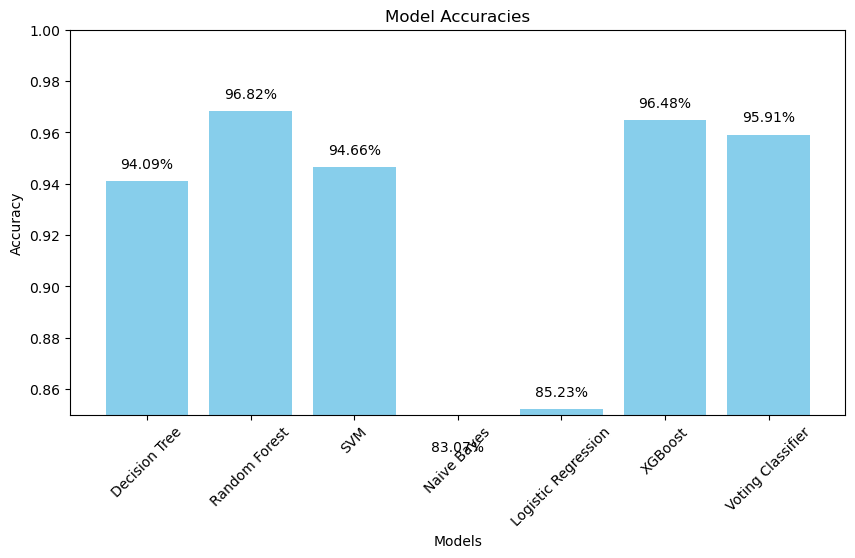

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


augmented_data = pd.read_csv("dataset.csv")

# Encode the categorical labels
label_encoder = LabelEncoder()
augmented_data['label'] = label_encoder.fit_transform(augmented_data['label'])

# Split the data into features and target variable
X = augmented_data.drop(columns=['label', 'price'])
y = augmented_data['label']

# Apply Min-Max scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Function to evaluate the model
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_.astype(str))
    return accuracy, report

# Initialize models with default parameters
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# Evaluate and collect the models
tuned_models = {}
for model_name, model in models.items():
    accuracy, report = evaluate_model(model, X_train, X_test, y_train, y_test)
    tuned_models[model_name] = model
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    #print("Classification Report:\n", report)
    print("="*60)

# Create a voting classifier
voting_clf = VotingClassifier(estimators=[
    ('dt', tuned_models["Decision Tree"]),
    ('rf', tuned_models["Random Forest"]),
    ('svm', tuned_models["SVM"]),
    ('nb', tuned_models["Naive Bayes"]),
    ('lr', tuned_models["Logistic Regression"]),
    ('xgb', tuned_models["XGBoost"])
], voting='soft')

# Evaluate the voting classifier
voting_accuracy, voting_report = evaluate_model(voting_clf, X_train, X_test, y_train, y_test)
accuracy_dict = {name: evaluate_model(model, X_train, X_test, y_train, y_test)[0] for name, model in tuned_models.items()}
accuracy_dict["Voting Classifier"] = voting_accuracy

print(f"Voting Classifier Accuracy: {voting_accuracy * 100:.2f}%")
#print("Voting Classifier Classification Report:\n", voting_report)

# Plot the accuracies
plt.figure(figsize=(10, 5))
plt.bar(accuracy_dict.keys(), accuracy_dict.values(), color='skyblue')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracies')
plt.ylim(0.85, 1.00)
for i, v in enumerate(accuracy_dict.values()):
    plt.text(i, v + 0.005, f"{v * 100:.2f}%", ha='center')
plt.xticks(rotation=45)
plt.show()
